In [89]:
# import our librairies
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [91]:
df =pd.read_csv("spam_and_ham_classification.csv")
df

,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...
...,...,...
9984,ham,this would be a great tragedy for all concerne...
9985,ham,"hello , welcome to medzonline filamentous shop..."
9986,ham,this is amazing stuff add some inches fast saf...
9987,spam,author jra date escapenumber escapenumber esca...


In [34]:
df.head()

,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   9989 non-null   object
 1   text    9989 non-null   object
dtypes: object(2)
memory usage: 156.2+ KB


In [38]:
df.describe()

,label,text
count,9989,9989
unique,2,9989
top,ham,into the kingdom of god and those that are ent...
freq,5294,1


In [40]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [42]:
df.duplicated().value_counts()

False    9989
Name: count, dtype: int64

In [44]:
df

,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...
...,...,...
9984,ham,this would be a great tragedy for all concerne...
9985,ham,"hello , welcome to medzonline filamentous shop..."
9986,ham,this is amazing stuff add some inches fast saf...
9987,spam,author jra date escapenumber escapenumber esca...


In [165]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])
y = df["label"]

In [167]:
vectorizer = CountVectorizer()
# vectorizer.fit_transform(df["text"])

In [169]:
smote =SMOTE(random_state = 42)
x_counts= vectorizer.fit_transform(df["text"])
x_balanced , y_balanced = smote.fit_resample(x_counts,y)

In [170]:
print(y_balanced.value_counts())

label
0    5294
1    5294
Name: count, dtype: int64


In [171]:
df["label"].value_counts()

label
0    5294
1    4695
Name: count, dtype: int64

In [48]:
df.columns

Index(['label', 'text'], dtype='object')

In [145]:

# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df["label"] = le.fit_transform(df["label"])

In [52]:
# x= vectorizer.fit_transform(df["text"])
# y = df["label"]

In [175]:
df['label'].value_counts()


label
0    5294
1    4695
Name: count, dtype: int64

In [54]:
df

,label,text
0,0,into the kingdom of god and those that are ent...
1,1,there was flow at hpl meter 1505 on april firs...
2,0,take a look at this one campaign for bvyhprice...
3,1,somu wrote actually thats what i was looking f...
4,1,fathi boudra wrote i fixed the issue in the sv...
...,...,...
9984,0,this would be a great tragedy for all concerne...
9985,0,"hello , welcome to medzonline filamentous shop..."
9986,0,this is amazing stuff add some inches fast saf...
9987,1,author jra date escapenumber escapenumber esca...


In [177]:
x_train, x_test , y_train , y_test = train_test_split(x_balanced,y_balanced, test_size = 0.2 , random_state = 42)

In [179]:
Mu = MultinomialNB(alpha=1)
Mu.fit(x_train,y_train)

MultinomialNB(alpha=1)

In [181]:
y_pred = Mu.predict(x_test)

In [183]:
print(f"Accuracy: {accuracy_score(y_test,y_pred):.3f}")

Accuracy: 0.973


In [185]:
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Confusion Matrix: [[1023   39]
 [  19 1037]]


In [187]:
print(f" clasification report:\n {classification_report(y_test, y_pred)}")

 clasification report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      1062
           1       0.96      0.98      0.97      1056

    accuracy                           0.97      2118
   macro avg       0.97      0.97      0.97      2118
weighted avg       0.97      0.97      0.97      2118



In [189]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[1023   39]
 [  19 1037]]


In [191]:
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      1062
           1       0.96      0.98      0.97      1056

    accuracy                           0.97      2118
   macro avg       0.97      0.97      0.97      2118
weighted avg       0.97      0.97      0.97      2118



In [194]:
cr = classification_report(y_test, y_pred)


In [206]:
# checking for overfitting 
print(Mu.score(x_train,y_train))
print(Mu.score(x_test,y_test))

0.9819362455726092
0.9726156751652503


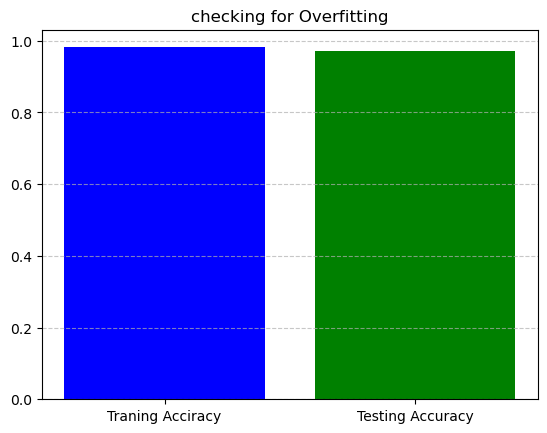

In [208]:
scores = [Mu.score(x_train,y_train),Mu.score(x_test,y_test)]
labels = ["Traning Acciracy", "Testing Accuracy"]

plt.bar( labels,scores, color=["blue","green"])
plt.title("checking for Overfitting")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


<Figure size 1500x800 with 0 Axes>

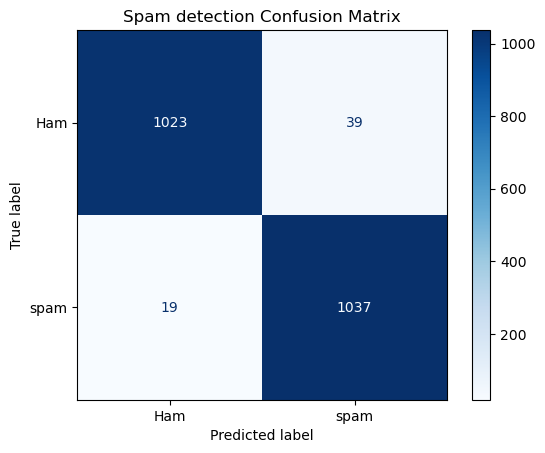

In [209]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay( confusion_matrix= cm , display_labels=["Ham","spam"] )
plt.figure(figsize=(15,8))
disp.plot(cmap="Blues",values_format="d")
plt.title("Spam detection Confusion Matrix")
plt.show()

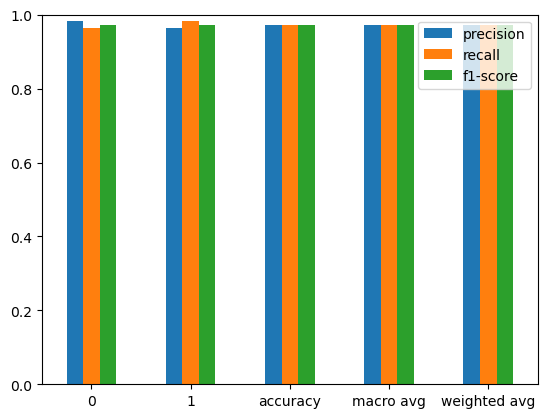

In [211]:
output_dict=True
report = classification_report(y_test, y_pred,output_dict=True)
d_report = pd.DataFrame(report).transpose()
d_report[['precision', 'recall', 'f1-score']].plot(kind="bar")
plt.ylim(0, 1)
plt.xticks(rotation =360)
plt.show()

In [85]:
d_report.columns

Index(['precision', 'recall', 'f1-score', 'support'], dtype='object')

In [115]:
pip install pygame


Note: you may need to restart the kernel to use updated packages.


In [204]:
# ways of impoving algorithm
# oversampling 
# undersampling
# fine turining 
# regularization 
# cross validaation 
# pruninig 